Name-Riya choudhary

Subject-Computer vision lab

CUID-CU24250251

**Experiment No. 9**

Object Detection and Recognition using Deep Learning Models on Standard Image Datasets

In [1]:
!pip install ultralytics opencv-python matplotlib -q
print("Libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.8 MB/s eta 0:00:00
Libraries installed successfully!


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from ultralytics import YOLO
print("Libraries imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries imported successfully!


In [3]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = next(iter(uploaded))
print("Image uploaded successfully!")
print("Image path:", IMAGE_PATH)

Saving input.png to input.png
Image uploaded successfully!
Image path: input.png


Image loaded successfully!
Image shape: (1086, 1448, 3)


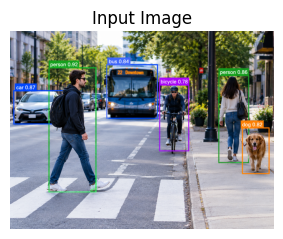

In [5]:
IMAGE_PATH = "input.png"
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError("Could not find input.png")
print("Image loaded successfully!")
print("Image shape:", img.shape)
# Display the input image
plt.figure(figsize=(6, 2.5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis("off")
plt.tight_layout()
plt.show()

Image preprocessing completed successfully!
Original size: (1448, 1086)
Resized size: (640, 480)


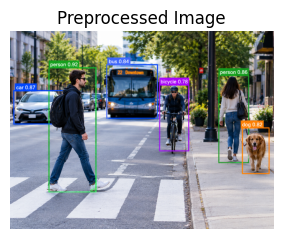

In [7]:
INFER_SIZE = 640
h, w = img.shape[:2]
scale = INFER_SIZE / max(h, w)
new_w = int(w * scale)
new_h = int(h * scale)
resized_img = cv2.resize(img, (new_w, new_h))
print("Image preprocessing completed successfully!")
print("Original size:", (w, h))
print("Resized size:", (new_w, new_h))
# Display resized image
plt.figure(figsize=(6, 2.5))
plt.imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
plt.title("Preprocessed Image")
plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
from ultralytics import YOLO
print("Loading YOLOv8 model...")
model_nano = YOLO("yolov8n.pt")
print("YOLOv8 model loaded successfully!")

Loading YOLOv8 model...
YOLOv8 model loaded successfully!


In [11]:
print("Running YOLOv8 object detection...")
start_time = time.perf_counter()
results = model_nano.predict(
    source=IMAGE_PATH,
    imgsz=INFER_SIZE,
    conf=0.25,
    verbose=False
)
end_time = time.perf_counter()
result = results[0]
print("Object detection completed successfully!")
print("Number of detected objects:", len(result.boxes))
print(f"Inference time: {(end_time - start_time) * 1000:.2f} ms")

Running YOLOv8 object detection...
Object detection completed successfully!
Number of detected objects: 15
Inference time: 8368.32 ms


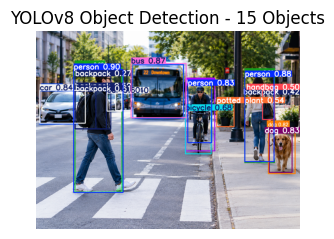

In [13]:
annotated_image = result.plot()
# Convert BGR to RGB
annotated_image_rgb = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)
# Display in smaller size
plt.figure(figsize=(6, 2.5))
plt.imshow(annotated_image_rgb)
plt.title(f"YOLOv8 Object Detection - {len(result.boxes)} Objects")
plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
print("YOLOv8 Detection Results")
print("-------------------------")
for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    label = model_nano.names[class_id]

    print(f"Object: {label:12s} | Confidence: {confidence:.2f}")

YOLOv8 Detection Results
-------------------------
Object: person       | Confidence: 0.90
Object: person       | Confidence: 0.88
Object: bus          | Confidence: 0.87
Object: car          | Confidence: 0.84
Object: dog          | Confidence: 0.83
Object: person       | Confidence: 0.83
Object: bicycle      | Confidence: 0.68
Object: backpack     | Confidence: 0.61
Object: car          | Confidence: 0.60
Object: potted plant | Confidence: 0.54
Object: handbag      | Confidence: 0.50
Object: backpack     | Confidence: 0.50
Object: backpack     | Confidence: 0.42
Object: car          | Confidence: 0.40
Object: backpack     | Confidence: 0.27


In [15]:
confidences = [
    float(box.conf[0])
    for box in result.boxes
]
print("Detection Confidence Analysis")
print("-----------------------------")
print("Number of detections:", len(confidences))
print(f"Mean confidence: {np.mean(confidences):.2f}")
print(f"Minimum confidence: {np.min(confidences):.2f}")
print(f"Maximum confidence: {np.max(confidences):.2f}")
low_confidence = [
    c for c in confidences
    if c < 0.40
]
print(
    "Low-confidence detections (< 0.40):",
    len(low_confidence)
)

Detection Confidence Analysis
-----------------------------
Number of detections: 15
Mean confidence: 0.64
Minimum confidence: 0.27
Maximum confidence: 0.90
Low-confidence detections (< 0.40): 1


In [16]:
print("Loading YOLOv8s model...")
model_small = YOLO("yolov8s.pt")
print("YOLOv8s model loaded successfully!")
# Run YOLOv8s
start_time = time.perf_counter()
results_small = model_small.predict(
    source=IMAGE_PATH,
    imgsz=INFER_SIZE,
    conf=0.25,
    verbose=False
)
end_time = time.perf_counter()
result_small = results_small[0]
small_time = end_time - start_time
# Calculate average confidence
small_confidences = [
    float(box.conf[0])
    for box in result_small.boxes
]
avg_conf_small = (
    np.mean(small_confidences)
    if small_confidences
    else 0
)
# YOLOv8n average confidence
avg_conf_nano = np.mean(confidences)
print("\nYOLOv8n vs YOLOv8s")
print("-------------------")
print(f"YOLOv8n detections       : {len(result.boxes)}")
print(f"YOLOv8n average confidence: {avg_conf_nano:.2f}")
print(f"YOLOv8n inference time   : {(end_time - start_time) * 1000:.2f} ms")
print()
print(f"YOLOv8s detections       : {len(result_small.boxes)}")
print(f"YOLOv8s average confidence: {avg_conf_small:.2f}")
print(f"YOLOv8s inference time   : {small_time * 1000:.2f} ms")

Loading YOLOv8s model...
YOLOv8s model loaded successfully!

YOLOv8n vs YOLOv8s
-------------------
YOLOv8n detections       : 15
YOLOv8n average confidence: 0.64
YOLOv8n inference time   : 669.28 ms

YOLOv8s detections       : 16
YOLOv8s average confidence: 0.68
YOLOv8s inference time   : 669.28 ms


In [17]:
# Step 11: Correct YOLOv8n vs YOLOv8s comparison

# Recalculate YOLOv8n inference time
start_time = time.perf_counter()

results_nano_check = model_nano.predict(
    source=IMAGE_PATH,
    imgsz=INFER_SIZE,
    conf=0.25,
    verbose=False
)

nano_time = time.perf_counter() - start_time
result_nano_check = results_nano_check[0]

nano_confidences = [
    float(box.conf[0])
    for box in result_nano_check.boxes
]

avg_conf_nano = np.mean(nano_confidences)
print("Corrected Model Comparison")
print("---------------------------")
print(f"YOLOv8n detections        : {len(result_nano_check.boxes)}")
print(f"YOLOv8n average confidence: {avg_conf_nano:.2f}")
print(f"YOLOv8n inference time    : {nano_time * 1000:.2f} ms")
print()
print(f"YOLOv8s detections        : {len(result_small.boxes)}")
print(f"YOLOv8s average confidence: {avg_conf_small:.2f}")
print(f"YOLOv8s inference time    : {small_time * 1000:.2f} ms")

Corrected Model Comparison
---------------------------
YOLOv8n detections        : 15
YOLOv8n average confidence: 0.64
YOLOv8n inference time    : 331.36 ms

YOLOv8s detections        : 16
YOLOv8s average confidence: 0.68
YOLOv8s inference time    : 669.28 ms


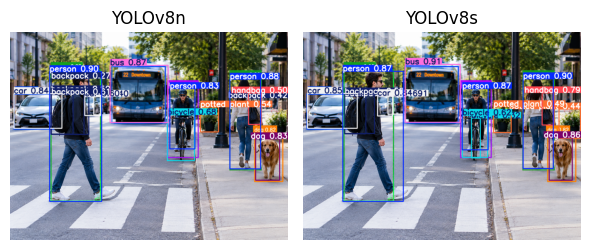

In [19]:
# Step 12: Compare YOLOv8n and YOLOv8s visually

annotated_nano = result_nano_check.plot()
annotated_small = result_small.plot()

plt.figure(figsize=(6, 2.5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(annotated_nano, cv2.COLOR_BGR2RGB))
plt.title("YOLOv8n")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(annotated_small, cv2.COLOR_BGR2RGB))
plt.title("YOLOv8s")
plt.axis("off")

plt.tight_layout()
plt.show()